In [2]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

In [ ]:
ohlcv = pd.read_csv('../data/raw/ohlcv_data.csv', parse_dates=['date']).set_index('date')
signals_all = pd.read_csv('../data/raw/primary_signals.csv', parse_dates=['date']).set_index('date')

# ── Oil-only slice ──────────────────────────────────────────────────────────
oil = ohlcv[ohlcv['instrument'] == 'cl1s'].copy()
oil = oil.sort_index()

close = oil['close']
high  = oil['high']
low   = oil['low']
open_ = oil['open']

# Primary signal for CL1S (available from Jan 2020)
signal_cl1s = signals_all['cl1s']

print(f'Oil price history : {close.index.min().date()} → {close.index.max().date()} ({len(close):,} days)')
print(f'Primary signal    : {signal_cl1s.index.min().date()} → {signal_cl1s.index.max().date()} ({len(signal_cl1s):,} days)')
print(f'\nSignal distribution:\n{signal_cl1s.value_counts().sort_index()}')

NameError: name 'ROOT' is not defined

In [4]:
def ewma_daily_vol(close: pd.Series, span: int = 100) -> pd.Series:
    """
    - Exponentially weighted moving average of daily log-return volatility.
    - This is the estimator recommended in Lopez de Prado (2018) for calibrating
    triple-barrier widths
    - Weights recent observations more heavily, making barriers adaptive to current market regimes
    """
    log_returns = np.log(close / close.shift(1)).dropna()
    vol = log_returns.ewm(span=span, min_periods=span).std()
    return vol.reindex(close.index)


def rolling_daily_vol(close: pd.Series, window: int = 20) -> pd.Series:
    """
    - Simple rolling standard deviation of daily log returns
    - Equal-weighted (more baseline)
    """
    log_returns = np.log(close / close.shift(1))
    return log_returns.rolling(window=window, min_periods=window).std()


def parkinson_daily_vol(high: pd.Series, low: pd.Series, window: int = 20) -> pd.Series:
    """
    - Parkinson (1980) range-based volatility estimator.
    - Uses intraday high/low to estimate volatility (5x more efficinet)
    """
    log_hl = np.log(high / low)
    parkinson_sq = (log_hl ** 2) / (4 * np.log(2))
    return np.sqrt(parkinson_sq.rolling(window=window, min_periods=window).mean())


def garman_klass_daily_vol(
    open_: pd.Series,
    high: pd.Series,
    low: pd.Series,
    close: pd.Series,
    window: int = 20,
) -> pd.Series:
    """
    - Garman-Klass (1980) volatility estimator
    - Incorporates open, high, low, close for a more efficient estimate than either close-to-close or Parkinson alone.
    """
    log_hl = np.log(high / low)
    log_co = np.log(close / open_)
    gk = 0.5 * log_hl ** 2 - (2 * np.log(2) - 1) * log_co ** 2
    return np.sqrt(gk.rolling(window=window, min_periods=window).mean())


In [5]:
def create_barriers(
    close: pd.Series,
    signal: pd.Series,
    vol: pd.Series,
    num_days: int = 10,
    take_profit_mult: float = 2.0,
    stop_loss_mult: float = 2.0,
) -> pd.DataFrame:
    """
    Creates a simple triple-barrier table for one instrument.

    Includes signal = -1, 0, and +1.

    Timeout is num_days trading observations later using the close price index.
    """

    close = close.sort_index()
    signal = signal.sort_index()
    vol = vol.sort_index()

    # Align close, signal, and volatility
    df = pd.DataFrame({
        "close": close,
        "primary_signal": signal,
        "vol": vol,
    })

    df = df.dropna(subset=["close", "primary_signal", "vol"]).copy()
    df["primary_signal"] = df["primary_signal"].astype(int)

    # Use the full close price index to calculate timeout dates
    price_series = close.dropna().sort_index()
    price_index = price_series.index

    # Find where each event date sits in the full oil price history
    event_positions = price_index.get_indexer(df.index)

    # Timeout is num_days trading rows later
    timeout_positions = event_positions + num_days

    # Keep only rows where timeout date exists
    valid_timeout = (event_positions >= 0) & (timeout_positions < len(price_index))

    df = df.loc[valid_timeout].copy()
    timeout_positions = timeout_positions[valid_timeout]

    # Add timeout date and timeout close
    df["timeout_date"] = price_index[timeout_positions]
    df["timeout_close"] = price_series.iloc[timeout_positions].values

    # For signal = 0, treat barriers as normal upper/lower barriers
    # TP above close, SL below close
    barrier_side = df["primary_signal"].replace(0, 1)

    df["tp"] = df["close"] * (1 + barrier_side * take_profit_mult * df["vol"])
    df["sl"] = df["close"] * (1 - barrier_side * stop_loss_mult * df["vol"])

    df = df.reset_index().rename(columns={"index": "date"})

    return df[
        [
            "date",
            "close",
            "primary_signal",
            "vol",
            "tp",
            "sl",
            "timeout_date",
            "timeout_close",
        ]
    ]

In [6]:
vol = ewma_daily_vol(close, span=100)

barriers = create_barriers(
    close=close,
    signal=signal_cl1s,
    vol=vol,
    num_days=10,
    take_profit_mult=2.0,
    stop_loss_mult=2.0,
)

barriers.head()

,date,close,primary_signal,vol,tp,sl,timeout_date,timeout_close
0,2020-01-03,25.553469,0,0.019937,26.572369,24.534569,2020-01-17,23.729602
1,2020-01-06,25.642633,0,0.019740,26.654987,24.630279,2020-01-21,23.648586
2,2020-01-07,25.411618,-1,0.019602,24.415356,26.407881,2020-01-22,22.984255
3,2020-01-08,24.159275,0,0.020736,25.161193,23.157357,2020-01-23,22.518412
4,2020-01-09,24.139011,0,0.020530,25.130174,23.147848,2020-01-24,21.951300


In [7]:
def apply_triple_barrier_labels(
    barriers: pd.DataFrame,
    close: pd.Series,
) -> pd.DataFrame:
    """
    Applies triple-barrier labels to the barrier table.

    triple_barrier_label:
        1  = upper barrier touched first
       -1  = lower barrier touched first
        0  = neither touched before timeout

    metalabel:
        1   = primary_signal matches triple_barrier_label
        0   = primary_signal is opposite to triple_barrier_label
        0.5 = neutral / unclear case
    """

    close = close.dropna().sort_index()
    labelled = barriers.copy()

    triple_barrier_labels = []
    touch_dates = []
    touch_prices = []
    touched_barriers = []

    for _, row in labelled.iterrows():
        start_date = row["date"]
        timeout_date = row["timeout_date"]

        tp = row["tp"]
        sl = row["sl"]

        upper_barrier = max(tp, sl)
        lower_barrier = min(tp, sl)

        price_path = close.loc[
            (close.index > start_date) & (close.index <= timeout_date)
        ]

        label = 0
        touch_date = timeout_date
        touch_price = row.get("timeout_close", np.nan)
        touched_barrier = "timeout"

        for current_date, current_close in price_path.items():

            if current_close >= upper_barrier:
                label = 1
                touch_date = current_date
                touch_price = current_close
                touched_barrier = "upper"
                break

            elif current_close <= lower_barrier:
                label = -1
                touch_date = current_date
                touch_price = current_close
                touched_barrier = "lower"
                break

        triple_barrier_labels.append(label)
        touch_dates.append(touch_date)
        touch_prices.append(touch_price)
        touched_barriers.append(touched_barrier)

    labelled["triple_barrier_label"] = triple_barrier_labels
    labelled["touch_date"] = touch_dates
    labelled["touch_price"] = touch_prices
    labelled["touched_barrier"] = touched_barriers

    # Default metalabel is 0.5
    labelled["metalabel"] = 0.5

    # Correct:
    # primary_signal =  1 and TB =  1
    # primary_signal = -1 and TB = -1
    # primary_signal =  0 and TB =  0
    correct = labelled["primary_signal"] == labelled["triple_barrier_label"]

    # Wrong:
    # primary_signal =  1 and TB = -1
    # primary_signal = -1 and TB =  1
    wrong = (
        labelled["primary_signal"].isin([1, -1])
        & labelled["triple_barrier_label"].isin([1, -1])
        & (labelled["primary_signal"] != labelled["triple_barrier_label"])
    )

    labelled.loc[correct, "metalabel"] = 1
    labelled.loc[wrong, "metalabel"] = 0

    return labelled

In [11]:
# %%
barriers_labelled = apply_triple_barrier_labels(
    barriers=barriers,
    close=close,
)

barriers_labelled[
    ["date", "primary_signal", "triple_barrier_label", "metalabel"]
]

barriers_labelled.head()

df = barriers_labelled

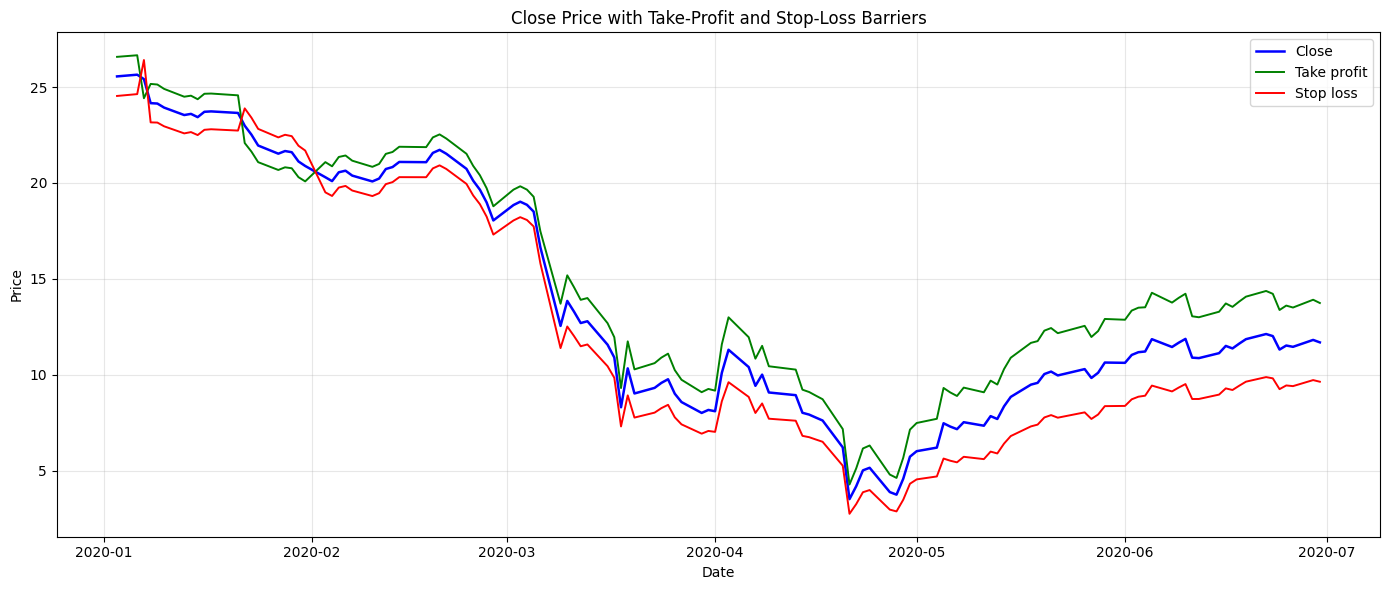

In [12]:
def plot_full_barrier_series(
    labelled: pd.DataFrame,
    start_date: str | None = None,
    end_date: str | None = None,
):
    """
    Plots the full time series of:
    - close price
    - take-profit barrier
    - stop-loss barrier

    This shows how the barriers change over time for every event/date.
    """

    df = labelled.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date")

    if start_date is not None:
        df = df[df["date"] >= pd.to_datetime(start_date)]

    if end_date is not None:
        df = df[df["date"] <= pd.to_datetime(end_date)]

    plt.figure(figsize=(14, 6))

    plt.plot(
        df["date"],
        df["close"],
        color="blue",
        linewidth=1.8,
        label="Close"
    )

    plt.plot(
        df["date"],
        df["tp"],
        color="green",
        linewidth=1.4,
        label="Take profit"
    )

    plt.plot(
        df["date"],
        df["sl"],
        color="red",
        linewidth=1.4,
        label="Stop loss"
    )

    plt.title("Close Price with Take-Profit and Stop-Loss Barriers")
    plt.xlabel("Date")
    plt.ylabel("Price")

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_full_barrier_series(barriers_labelled, start_date="2020-01-01", end_date="2020-06-30")

In [13]:
mode="primary_line"    # primary signal controls line colour, metalabel controls background
mode="metalabel_line"  # metalabel controls line colour, primary signal controls background

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def plot_close_with_primary_and_metalabel(
    labelled: pd.DataFrame,
    mode: str = "primary_line",
    start_date: str | None = None,
    end_date: str | None = None,
):
    """
    Plot close price with colours based on primary_signal and metalabel.

    Modes:
    - mode="primary_line":
        line colour       = primary_signal
        background colour = metalabel

    - mode="metalabel_line":
        line colour       = metalabel
        background colour = primary_signal
    """

    df = labelled.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    if start_date is not None:
        df = df[df["date"] >= pd.to_datetime(start_date)]

    if end_date is not None:
        df = df[df["date"] <= pd.to_datetime(end_date)]

    df = df.reset_index(drop=True)

    if mode not in ["primary_line", "metalabel_line"]:
        raise ValueError("mode must be either 'primary_line' or 'metalabel_line'.")

    primary_colours = {
        1: "green",
        0: "blue",
        -1: "red",
    }

    metalabel_colours = {
        1.0: "green",
        0.5: "orange",
        0.0: "red",
    }

    def get_primary_colour(value):
        return primary_colours.get(int(value), "grey")

    def get_metalabel_colour(value):
        return metalabel_colours.get(float(value), "grey")

    plt.figure(figsize=(15, 6))

    for i in range(len(df) - 1):

        if mode == "primary_line":
            line_colour = get_primary_colour(df.loc[i, "primary_signal"])
            background_colour = get_metalabel_colour(df.loc[i, "metalabel"])

        elif mode == "metalabel_line":
            line_colour = get_metalabel_colour(df.loc[i, "metalabel"])
            background_colour = get_primary_colour(df.loc[i, "primary_signal"])

        # Background shading
        plt.axvspan(
            df.loc[i, "date"],
            df.loc[i + 1, "date"],
            color=background_colour,
            alpha=0.08,
        )

        # Close price line
        plt.plot(
            [df.loc[i, "date"], df.loc[i + 1, "date"]],
            [df.loc[i, "close"], df.loc[i + 1, "close"]],
            color=line_colour,
            linewidth=2,
        )

    primary_legend = [
        Line2D([0], [0], color="green", linewidth=2, label="Primary signal +1"),
        Line2D([0], [0], color="blue", linewidth=2, label="Primary signal 0"),
        Line2D([0], [0], color="red", linewidth=2, label="Primary signal -1"),
    ]

    metalabel_legend = [
        Line2D([0], [0], color="green", linewidth=2, label="Metalabel 1"),
        Line2D([0], [0], color="orange", linewidth=2, label="Metalabel 0.5"),
        Line2D([0], [0], color="red", linewidth=2, label="Metalabel 0"),
    ]

    primary_background_legend = [
        Patch(facecolor="green", alpha=0.08, label="Primary signal +1 background"),
        Patch(facecolor="blue", alpha=0.08, label="Primary signal 0 background"),
        Patch(facecolor="red", alpha=0.08, label="Primary signal -1 background"),
    ]

    metalabel_background_legend = [
        Patch(facecolor="green", alpha=0.08, label="Metalabel 1 background"),
        Patch(facecolor="orange", alpha=0.08, label="Metalabel 0.5 background"),
        Patch(facecolor="red", alpha=0.08, label="Metalabel 0 background"),
    ]

    if mode == "primary_line":
        legend_handles = primary_legend + metalabel_background_legend
        title = "Close Price: Primary Signal Line Colour with Metalabel Background"

    else:
        legend_handles = metalabel_legend + primary_background_legend
        title = "Close Price: Metalabel Line Colour with Primary Signal Background"

    plt.legend(handles=legend_handles, loc="best")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

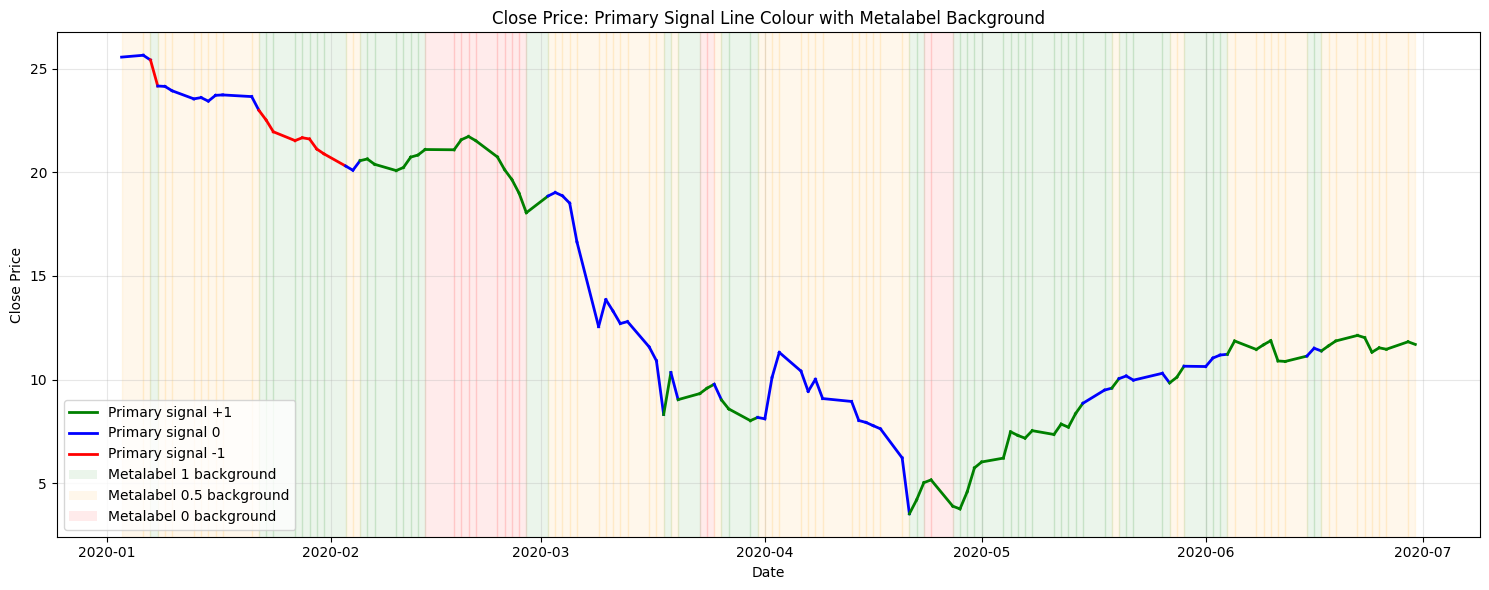

In [10]:
plot_close_with_primary_and_metalabel(
    labelled=barriers_labelled,
    mode="primary_line",
    start_date="2020-01-01",
    end_date="2020-06-30",
)

In [14]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def plot_close_with_tb_and_signal(
    labelled: pd.DataFrame,
    mode: str = "tb_line",
    start_date: str | None = None,
    end_date: str | None = None,
):
    """
    Plots close price with primary signal and triple barrier label.

    Modes:
    - mode="tb_line":
        line colour       = triple_barrier_label
        background colour = primary_signal

    - mode="signal_line":
        line colour       = primary_signal
        background colour = triple_barrier_label
    """

    df = labelled.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    if start_date is not None:
        df = df[df["date"] >= pd.to_datetime(start_date)]

    if end_date is not None:
        df = df[df["date"] <= pd.to_datetime(end_date)]

    df = df.reset_index(drop=True)

    if mode not in ["tb_line", "signal_line"]:
        raise ValueError("mode must be either 'tb_line' or 'signal_line'.")

    colours = {
        1: "green",
        0: "blue",
        -1: "red",
    }

    def get_colour(value):
        return colours[int(value)]

    plt.figure(figsize=(15, 6))

    for i in range(len(df) - 1):

        if mode == "tb_line":
            line_value = df.loc[i, "triple_barrier_label"]
            background_value = df.loc[i, "primary_signal"]

        elif mode == "signal_line":
            line_value = df.loc[i, "primary_signal"]
            background_value = df.loc[i, "triple_barrier_label"]

        # Background shading
        plt.axvspan(
            df.loc[i, "date"],
            df.loc[i + 1, "date"],
            color=get_colour(background_value),
            alpha=0.08,
        )

        # Close price line
        plt.plot(
            [df.loc[i, "date"], df.loc[i + 1, "date"]],
            [df.loc[i, "close"], df.loc[i + 1, "close"]],
            color=get_colour(line_value),
            linewidth=2,
        )

    tb_legend = [
        Line2D([0], [0], color="green", linewidth=2, label="TB label +1"),
        Line2D([0], [0], color="blue", linewidth=2, label="TB label 0"),
        Line2D([0], [0], color="red", linewidth=2, label="TB label -1"),
    ]

    signal_legend = [
        Line2D([0], [0], color="green", linewidth=2, label="Primary signal +1"),
        Line2D([0], [0], color="blue", linewidth=2, label="Primary signal 0"),
        Line2D([0], [0], color="red", linewidth=2, label="Primary signal -1"),
    ]

    tb_background_legend = [
        Patch(facecolor="green", alpha=0.08, label="TB label +1 background"),
        Patch(facecolor="blue", alpha=0.08, label="TB label 0 background"),
        Patch(facecolor="red", alpha=0.08, label="TB label -1 background"),
    ]

    signal_background_legend = [
        Patch(facecolor="green", alpha=0.08, label="Primary signal +1 background"),
        Patch(facecolor="blue", alpha=0.08, label="Primary signal 0 background"),
        Patch(facecolor="red", alpha=0.08, label="Primary signal -1 background"),
    ]

    if mode == "tb_line":
        legend_handles = tb_legend + signal_background_legend
        title = "Close Price: Triple Barrier Line Colour with Primary Signal Shading"

    else:
        legend_handles = signal_legend + tb_background_legend
        title = "Close Price: Primary Signal Line Colour with Triple Barrier Shading"

    plt.legend(handles=legend_handles, loc="best")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

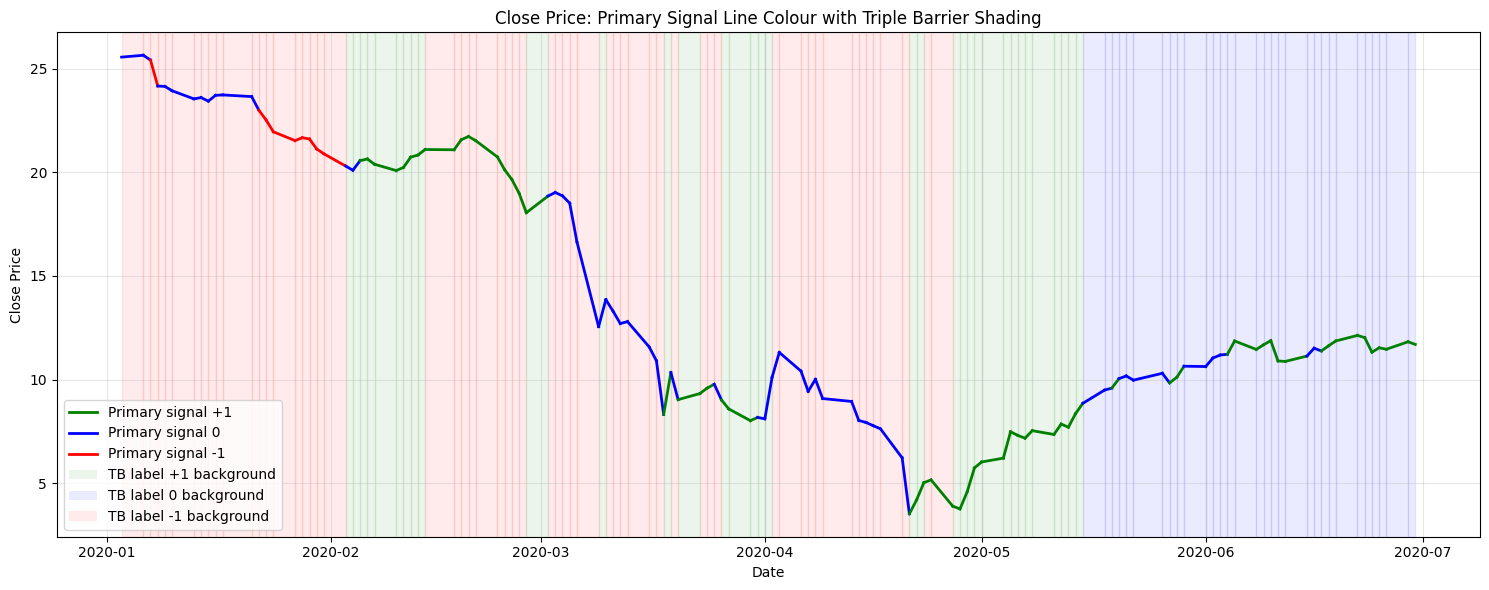

In [15]:
plot_close_with_tb_and_signal(
    labelled=barriers_labelled,
    mode="signal_line",
    start_date="2020-01-01",
    end_date="2020-06-30",
)

In [16]:
print("Triple barrier label counts:")
print(barriers_labelled["triple_barrier_label"].value_counts().sort_index())

print("\nMetalabel counts:")
print(barriers_labelled["metalabel"].value_counts().sort_index())

Triple barrier label counts:
triple_barrier_label
-1    176
 0    200
 1    242
Name: count, dtype: int64

Metalabel counts:
metalabel
0.0     99
0.5    264
1.0    255
Name: count, dtype: int64


In [17]:
def run_triple_barrier_pipeline(
    instrument: str = "cl1s",
    ohlcv_path: str = "../data/raw/ohlcv_data.csv",
    signals_path: str = "../data/raw/primary_signals.csv",
    signal_column: str | None = None,
    volatility_method: str = "ewma",
    ewma_span: int = 100,
    volatility_window: int = 20,
    num_days: int = 10,
    take_profit_mult: float = 2.0,
    stop_loss_mult: float = 2.0,
    output_path: str | None = None,
    save_columns: list[str] | None = None,
) -> pd.DataFrame:
    """
    Run the full triple-barrier labelling workflow for one instrument.

    Parameters
    ----------
    instrument:
        Instrument code in the OHLCV file, for example "cl1s".
    ohlcv_path:
        Path to the raw OHLCV CSV.
    signals_path:
        Path to the primary-signals CSV.
    signal_column:
        Primary-signal column to use. Defaults to the same value as instrument.
    volatility_method:
        One of "ewma", "rolling", "parkinson", or "garman_klass".
    ewma_span:
        Span used when volatility_method="ewma".
    volatility_window:
        Window used by rolling, Parkinson, and Garman-Klass volatility estimators.
    num_days:
        Vertical barrier length in trading observations.
    take_profit_mult:
        Take-profit barrier width as a multiple of volatility.
    stop_loss_mult:
        Stop-loss barrier width as a multiple of volatility.
    output_path:
        Optional CSV path. If None, nothing is saved.
    save_columns:
        Optional subset of columns to save when output_path is provided.

    Returns
    -------
    pd.DataFrame
        Labelled triple-barrier dataframe with barrier, touch, triple-barrier label,
        and metalabel columns.
    """

    signal_column = instrument if signal_column is None else signal_column

    ohlcv_data = pd.read_csv(ohlcv_path, parse_dates=["date"]).set_index("date")
    signals_data = pd.read_csv(signals_path, parse_dates=["date"]).set_index("date")

    instrument_data = ohlcv_data[ohlcv_data["instrument"] == instrument].sort_index().copy()
    if instrument_data.empty:
        raise ValueError(f"No OHLCV rows found for instrument={instrument!r}")
    if signal_column not in signals_data.columns:
        raise ValueError(f"Signal column {signal_column!r} not found in {signals_path}")

    close_series = instrument_data["close"]
    high_series = instrument_data["high"]
    low_series = instrument_data["low"]
    open_series = instrument_data["open"]
    signal_series = signals_data[signal_column]

    volatility_method = volatility_method.lower()
    if volatility_method == "ewma":
        vol_series = ewma_daily_vol(close_series, span=ewma_span)
    elif volatility_method == "rolling":
        vol_series = rolling_daily_vol(close_series, window=volatility_window)
    elif volatility_method == "parkinson":
        vol_series = parkinson_daily_vol(high_series, low_series, window=volatility_window)
    elif volatility_method in {"garman_klass", "garman-klass", "gk"}:
        vol_series = garman_klass_daily_vol(
            open_=open_series,
            high=high_series,
            low=low_series,
            close=close_series,
            window=volatility_window,
        )
    else:
        raise ValueError(
            "volatility_method must be one of 'ewma', 'rolling', 'parkinson', or 'garman_klass'"
        )

    barrier_table = create_barriers(
        close=close_series,
        signal=signal_series,
        vol=vol_series,
        num_days=num_days,
        take_profit_mult=take_profit_mult,
        stop_loss_mult=stop_loss_mult,
    )
    labelled = apply_triple_barrier_labels(
        barriers=barrier_table,
        close=close_series,
    )

    if output_path is not None:
        columns_to_save = save_columns or ["date", "primary_signal", "triple_barrier_label", "metalabel"]
        labelled[columns_to_save].to_csv(output_path, index=False)

    return labelled